In [27]:
# Do an FFT of the Ti and Bmag data to find a more objective KH wave period. 
# Perform a wavelet spectrum analysis. Find peaks in wave power and return frequency and period

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import pyspedas
from pyspedas import mms_load_fpi,tinterpol
from pyspedas.mms import fpi,fgm
from pyspedas.mms.mms_orbit_plot import mms_orbit_plot
from pytplot import tplot, get_data, store_data, tlimit, options,tplot_names,tplot_options,timebar,time_string


In [29]:
trange =['2020-06-17/20:30:00','2020-06-18/01:30:00']

ion_vars = pyspedas.mms.mms_load_fpi(trange=trange,probe='2',data_rate='brst',datatype='dis-moms',  center_measurement=True,time_clip=True)
#fgm_vars = pyspedas.mms.mms_load_fgm(trange=trange, probe='2', data_rate='srvy',time_clip=True)


01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617202923_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617203153_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617203423_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617203653_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617203923_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617204153_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617204413_v3.4.0.cdf
01-Jun-26 19:00:24: Loading pydata/mms2/fpi/brst/l2/dis-moms/2020/06/17/mms2_fpi_brst_l2_dis-moms_20200617204643_v3.4.0.cdf
01-Jun-2

In [30]:

Ti_t_para_brst, Ti_para_brst= get_data('mms2_dis_temppara_brst')
Ti_t_perp_brst, Ti_perp_brst= get_data('mms2_dis_tempperp_brst')

ave_Ti_brst =[]
for i in range(len(Ti_para_brst)):
    ave_Ti_brst.append(np.mean([Ti_para_brst[i],Ti_perp_brst[i]]))

store_data('Ti_brst', data={'x':Ti_t_para_brst, 'y':ave_Ti_brst})
options(['Ti_brst'],'ytitle','$T_i$ brst \n [eV]')


MMS2_brst_Ti = pd.DataFrame({"times": Ti_t_para_brst, "Ti": ave_Ti_brst})


MMS2_brst_Ti['date'] = pd.to_datetime(MMS2_brst_Ti['times'],unit='s')

Vi_mms2 = 'mms2_dis_bulkv_gse_brst'
times_vi_mms2, data_vi_mms2 = get_data(Vi_mms2)

ni_mms2 = 'mms2_dis_numberdensity_brst'
times_ni_mms2, data_ni_mms2 = get_data(ni_mms2)


MMS2_ni = pd.DataFrame({"times": times_ni_mms2, "ni": data_ni_mms2})
MMS2_Vi = pd.DataFrame({"times": times_vi_mms2, "Vix": data_vi_mms2[:,0],"Viy": data_vi_mms2[:,1], "Viz": data_vi_mms2[:,2]})
MMS2_Vi['date'] = pd.to_datetime(MMS2_Vi['times'],unit='s')
MMS2_ni['date'] = pd.to_datetime(MMS2_ni['times'],unit='s')



# b_field_mms2 = 'mms2_fgm_b_gse_srvy_l2'
# times_b_mms2, data_b_mms2 = get_data(b_field_mms2)

# MMS2_srvy_B = pd.DataFrame({"times": times_b_mms2, "Bx": data_b_mms2[:,0],"By": data_b_mms2[:,1], "Bz": data_b_mms2[:,2],"Bmag": data_b_mms2[:,3]})

# MMS2_srvy_B['date'] = pd.to_datetime(MMS2_srvy_B['times'],unit='s')

In [31]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
# import pywt

# # ============================================================
# # Load data
# # ============================================================

# # Replace with your filename if needed
# filename = "brst_ave_Ti.csv"

# df = pd.read_csv(filename)

# print(df.columns)

# # ------------------------------------------------------------
# # Assumptions:
# #   - One column contains time
# #   - One column contains Ti
# #
# # Change these if needed
# # ------------------------------------------------------------

# time_col = df.columns[0]
# ti_col = df.columns[1]

# # # Convert time if timestamps
# # try:
# #     time = pd.to_datetime(df[time_col])
# #     t_seconds = (time - time.iloc[0]).dt.total_seconds().values
# # except:
# #     t_seconds = df[time_col].values

# Ti = df[ti_col].values

# # # Remove NaNs
# # mask = np.isfinite(Ti)
# # Ti = Ti[mask]
# # t_seconds = t_seconds[mask]

# t_seconds = Ti_t_para_brst


# print('Ti',Ti)


# print('t_seconds',t_seconds)
# # ============================================================
# # Sampling interval
# # ============================================================

# dt = np.median(np.diff(t_seconds))
# print('dt',dt)
# fs = 1.0 / dt

# print(f"Sampling interval dt = {dt:.4f} s")
# print(f"Sampling frequency fs = {fs:.4f} Hz")

# # ============================================================
# # Continuous Wavelet Transform (Morlet)
# # ============================================================

# # Frequency range of interest
# freqs = np.logspace(-3, np.log10(fs/2), 200)

# # Convert frequencies to scales
# wavelet = 'cmor1.5-1.0'

# central_freq = pywt.central_frequency(wavelet)
# scales = central_freq / (freqs * dt)

# # Perform CWT
# coefficients, frequencies = pywt.cwt(
#     Ti,
#     scales,
#     wavelet,
#     sampling_period=dt
# )

# # Wavelet power
# power = np.abs(coefficients) ** 2

# # ============================================================
# # Average power spectrum
# # ============================================================

# avg_power = np.mean(power, axis=1)

# # ============================================================
# # Find peaks in wavelet power
# # ============================================================

# peaks, properties = find_peaks(avg_power, prominence=np.std(avg_power))

# peak_freqs = frequencies[peaks]
# peak_powers = avg_power[peaks]

# # ============================================================
# # Compute wavelengths
# # ============================================================

# # Wavelength = 1 / frequency
# wavelengths = 1.0 / peak_freqs

# average_wavelength = np.mean(wavelengths)

# # ============================================================
# # OUTPUT RESULTS
# # ============================================================

# print("\n====================================")
# print("Peak frequencies in wavelet power:")
# print("====================================")

# for f, p in zip(peak_freqs, peak_powers):
#     print(f"Frequency = {f:.6f} Hz   Power = {p:.4e}")



# print("\n====================================")
# print(f"Average wavelength (period): {average_wavelength:.4f} s")
# print("====================================")




In [32]:
# peak_freqs_hz = frequencies[peaks]
# peak_freqs_mhz = peak_freqs_hz * 1000.0

# peak_periods_sec = 1.0 / peak_freqs_hz

# peak_powers = avg_power[peaks]

# average_period_sec = np.mean(peak_periods_sec)

# # =========================================================
# # Print results
# # =========================================================

# print("\n====================================================")
# print("Peak Frequencies, Periods, and Wavelet Power")
# print("====================================================")

# for f_hz, f_mhz, period, pwr in zip(
#     peak_freqs_hz,
#     peak_freqs_mhz,
#     peak_periods_sec,
#     peak_powers
# ):

#     print(
#         f"Frequency = {f_mhz:8.3f} mHz   "
#         f"Period = {period:8.3f} s   "
#         f"Power = {pwr:.4e}"
#     )

# print("====================================================")
# print(f"Average Period = {average_period_sec:.3f} s")
# print("====================================================")


In [33]:





# #%matplotlib widget

# fig = plt.figure(figsize=(10,5))

# plt.rcParams.update({'font.size': 12})
# # -----------------------------------------------------
# # Wavelet spectrum
# # -----------------------------------------------------

# ax1 = fig.add_subplot(211)
# ax1_plot = ax1.pcolormesh(pd.to_datetime(t_seconds,unit='s'),frequencies*1000, #Get frequencies in mHz
#                power, cmap='nipy_spectral',shading='auto')
# ax1.set_ylabel("Frequency (mHz)")
# ax1.set_yscale('log')
# ax1.tick_params( axis='x',labelbottom=False)

# fig.colorbar(ax1_plot, ax=ax1,label="$(eV)^2$", pad=0.0)


# ax2 = fig.add_subplot(212,sharex = ax1)
# ax2.plot(pd.to_datetime(t_seconds,unit='s'), Ti)

# ax2.set_ylabel('$T_i$ [eV]')

# plt.subplots_adjust(hspace=0.0)



# box = ax2.get_position()
# ax2.set_position([box.x0, box.y0, box.width * 0.85, box.height])
# # Put a legend to the right of the current axis
# #ax_B.legend(['$B_{x}$','$B_y$','$B_z$'],loc='center left', bbox_to_anchor=(1, 0.5))


# #fig.colorbar(omni_dis_plot, ax=ax_omni_dis, label="$keV/(cm^2~s~sr~keV)$", pad=0.0)

# #ax_omni_dis.tick_params( axis='x',labelbottom=False)

# # power = ax_omni_dis.pcolormesh(np.array(time_string(dis_energy.times)).astype("datetime64[ns]"),dis_energy.y[0],
# #                np.log10(np.transpose(dis_omni_flux.y[:,:])), cmap='nipy_spectral',shading='auto')
# # ax_omni_dis.set_ylabel('DIS OMNI \n [eV]')
# # ax_omni_dis.set_yscale('log')
# # fig.colorbar(omni_dis_plot, ax=ax_omni_dis,label="$keV/(cm^2~s~sr~keV)$", pad=0.0)


# # ax2 = fig.add_subplot(212,sharex=ax1)
# # pcm = ax2.pcolormesh(
# #     pd.to_datetime(t_seconds,unit='s'),
# #     frequencies,
# #     power,
# #     shading='auto'
# # )

# # ax2.set_yscale('log')

# # ax2.set_xlabel("Time")
# # ax2.set_ylabel("Frequency (Hz)")
# # #ax2.set_title("Wavelet Power Spectrum")
# # fig.colorbar(pcm, ax=ax2,label="$(eV)^2$", pad=0.0)

# # # cbar = plt.colorbar(pcm, ax=ax2)
# # # cbar.set_label("Power")

# # plt.tight_layout()

In [34]:
# # ------------------------------------------------------------
# # Average power spectrum
# # ------------------------------------------------------------
# print('peak power and corresponding frequency',peak_powers,peak_freqs)

# fig, ax = plt.subplots(figsize=(8, 5))

# ax.plot(frequencies*1000, avg_power) # get frequencies in mHz

# # Mark peaks
# ax.plot(peak_freqs*1000, peak_powers, 'ro')

# ax.set_xscale('log')
# ax.set_yscale('log')

# ax.set_xlabel("Frequency (mHz)")
# ax.set_ylabel("Average Wavelet Power")
# ax.set_title("Average Wavelet Power Spectrum")

# plt.tight_layout()
# plt.show()



In [35]:
# Find average Vix velocity from start and stop times of MSH

In [42]:

import pandas as pd
import numpy as np

# Load velocity data
df = MMS2_Vi

# Start/stop MSH_times
MSH_times = [
    1592432210.0000000,1592432300.0000000,
    1592433110.0000000,1592433180.0000000,
    1592433480.0000000,1592433520.0000000,
    1592433850.0000000,1592433990.0000000,
    1592434400.0000000,1592434530.0000000,
    1592436490.0000000,1592436600.0000000,
    1592437050.0000000,1592437180.0000000,
    1592437400.0000000,1592437510.0000000,
    1592437840.0000000,1592438000.0000000,
    1592438320.0000000,1592438420.0000000,
    1592438720.0000000,1592438880.0000000,
    1592439220.0000000,1592439360.0000000,
    1592439580.0000000,1592439700.0000000,
    1592439860.0000000,1592439990.0000000
]

# Compute average Vx in each interval
for i in range(0, len(MSH_times), 2):

    t1 = MSH_times[i]
    t2 = MSH_times[i+1]

    mask = (
        (df['times'] >= t1) &
        (df['times'] <= t2)
    )

    mean_vx = df.loc[mask, 'Vix'].mean()

    print(
        f"{t1:.0f} - {t2:.0f} : "
        f"Mean Vx = {mean_vx:.2f} km/s"
    )

vx_values = np.array([
    -176.79,
    -187.17,
    -180.38,
    -174.23,
    -197.87,
    -156.42,
    -159.02,
    -170.63,
    -171.38,
    -168.21,
    -190.39,
    -206.90,
    -181.79,
    -192.46
])

overall_average_vx = np.mean(vx_values)

print('overall_average_vx',overall_average_vx)

1592432210 - 1592432300 : Mean Vx = -176.79 km/s
1592433110 - 1592433180 : Mean Vx = -187.17 km/s
1592433480 - 1592433520 : Mean Vx = -180.38 km/s
1592433850 - 1592433990 : Mean Vx = -174.23 km/s
1592434400 - 1592434530 : Mean Vx = -197.87 km/s
1592436490 - 1592436600 : Mean Vx = -156.42 km/s
1592437050 - 1592437180 : Mean Vx = -159.02 km/s
1592437400 - 1592437510 : Mean Vx = -170.63 km/s
1592437840 - 1592438000 : Mean Vx = -171.38 km/s
1592438320 - 1592438420 : Mean Vx = -168.21 km/s
1592438720 - 1592438880 : Mean Vx = -190.39 km/s
1592439220 - 1592439360 : Mean Vx = -206.90 km/s
1592439580 - 1592439700 : Mean Vx = -181.79 km/s
1592439860 - 1592439990 : Mean Vx = -192.46 km/s
overall_average_vx -179.54571428571427


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pywt


def wavelet_spectrum_analysis(
    data,
    time_col,
    value_col,
    wavelet='cmor1.5-1.0',
    n_freqs=200,
    min_freq=None,
    max_freq=None,
    peak_prominence=None,
    plot=True
):
    """
    Perform wavelet spectrum analysis on a time series.

    Parameters
    ----------
    data : pandas.DataFrame or dict-like
        Data structure containing time and signal data.

    time_col : str
        Name of the time column.

    value_col : str
        Name of the signal column (e.g., Ti).

    wavelet : str
        PyWavelets wavelet name.

    n_freqs : int
        Number of frequencies in wavelet transform.

    min_freq : float or None
        Minimum frequency in Hz.

    max_freq : float or None
        Maximum frequency in Hz.

    peak_prominence : float or None
        Prominence threshold for peak detection.

    plot : bool
        If True, generate plots.

    Returns
    -------
    results : dict
        Dictionary containing:
            - frequencies
            - power
            - avg_power
            - peak_freqs_hz
            - peak_freqs_mhz
            - peak_periods_sec
            - peak_powers
            - average_period_sec
    """

    # =========================================================
    # Extract data
    # =========================================================

    time_raw = np.asarray(data[time_col])
    values = np.asarray(data[value_col])

    # Convert time to seconds
    try:
        time = pd.to_datetime(time_raw)
        t_seconds = (
            time - time.iloc[0]
        ).dt.total_seconds().values
    except:
        t_seconds = np.asarray(time_raw)

    # Remove NaNs
    mask = np.isfinite(values)

    values = values[mask]
    t_seconds = t_seconds[mask]

    # =========================================================
    # Sampling properties
    # =========================================================

    dt = np.median(np.diff(t_seconds))
    fs = 1.0 / dt

    if min_freq is None:
        min_freq = 1e-3

    if max_freq is None:
        max_freq = fs / 2.0

    # =========================================================
    # Frequency array
    # =========================================================

    freqs = np.logspace(
        np.log10(min_freq),
        np.log10(max_freq),
        n_freqs
    )

    # Convert frequency -> scale
    central_freq = pywt.central_frequency(wavelet)

    scales = central_freq / (freqs * dt)

    # =========================================================
    # Continuous Wavelet Transform
    # =========================================================

    coefficients, frequencies = pywt.cwt(
        values,
        scales,
        wavelet,
        sampling_period=dt
    )

    # Wavelet power
    power = np.abs(coefficients) ** 2

    # Average power spectrum
    avg_power = np.mean(power, axis=1)

    # =========================================================
    # Peak detection
    # =========================================================

    if peak_prominence is None:
        peak_prominence = np.std(avg_power)

    peaks, properties = find_peaks(
        avg_power,
        prominence=peak_prominence
    )

    peak_freqs_hz = frequencies[peaks]
    peak_freqs_mhz = peak_freqs_hz * 1000.0

    peak_periods_sec = 1.0 / peak_freqs_hz

    peak_powers = avg_power[peaks]

    average_period_sec = np.mean(peak_periods_sec)

    # =========================================================
    # Print results
    # =========================================================

    print("\n====================================================")
    print("Peak Frequencies, Periods, and Wavelet Power")
    print("====================================================")

    for f_hz, f_mhz, period, pwr in zip(
        peak_freqs_hz,
        peak_freqs_mhz,
        peak_periods_sec,
        peak_powers
    ):

        print(
            f"Frequency = {f_mhz:8.3f} mHz   "
            f"Period = {period:8.3f} s   "
            f"Power = {pwr:.4e}  eV^2"
        )

    print("====================================================")
    print(f"Average Period = {average_period_sec:.3f} s")
    print("====================================================")

    # =========================================================
    # Plotting
    # =========================================================

    if plot:

        fig = plt.figure(figsize=(10,5))
        
        plt.rcParams.update({'font.size': 12})
        # -----------------------------------------------------
        # Wavelet spectrum
        # -----------------------------------------------------
        
        ax1 = fig.add_subplot(311)
        ax1.set_title("Wavelet Power Spectrum")
        ax1_plot = ax1.pcolormesh(pd.to_datetime(t_seconds,unit='s'),frequencies*1000, #Get frequencies in mHz
        power, cmap='nipy_spectral',shading='auto')
        ax1.set_ylabel("Frequency (mHz)")
        ax1.set_yscale('log')
        ax1.set_ylim([0,100])
        ax1.tick_params( axis='x',labelbottom=False)
        
        fig.colorbar(ax1_plot, ax=ax1,label="$(eV)^2$", pad=0.0)
        
        # -----------------------------------------------------
        # Time series
        # -----------------------------------------------------
        ax2 = fig.add_subplot(312,sharex = ax1)
        ax2.plot(pd.to_datetime(t_seconds,unit='s'), df[value_col])
        ax2.set_ylabel('$T_i$ [eV]')
        ax2.tick_params( axis='x',labelbottom=False)

        ax3 = fig.add_subplot(313,sharex = ax1)
        ax3.plot(MMS2_Vi['date'],MMS2_Vi['Vix'])
        ax3.set_ylabel('$V_{ix}$ [km/s]')
        
        
        plt.subplots_adjust(hspace=0.0)
        
        
        
        box = ax2.get_position()
        ax2.set_position([box.x0, box.y0, box.width * 0.85, box.height])

        box = ax3.get_position()
        ax3.set_position([box.x0, box.y0, box.width * 0.85, box.height])
        for i in MSH_times:
            ax3.axvline(x = pd.to_datetime(i,unit='s'), color = 'darkgreen')
        
        # -----------------------------------------------------
        # Average power spectrum
        # -----------------------------------------------------

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(frequencies, avg_power)

        ax.plot(
            peak_freqs_hz,
            peak_powers,
            'ro',
            label='Peaks'
        )

        ax.set_xscale('log')
        ax.set_yscale('log')

        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Average Wavelet Power")

        ax.set_title("Average Wavelet Power Spectrum")

        ax.legend()

        plt.tight_layout()

        plt.show()

    # =========================================================
    # Return results
    # =========================================================

    results = {
        "frequencies": frequencies,
        "power": power,
        "avg_power": avg_power,
        "peak_freqs_hz": peak_freqs_hz,
        "peak_freqs_mhz": peak_freqs_mhz,
        "peak_periods_sec": peak_periods_sec,
        "peak_powers": peak_powers,
        "average_period_sec": average_period_sec,
    }

    return results


Peak Frequencies, Periods, and Wavelet Power
Frequency =    2.260 mHz   Period =  442.529 s   Power = 8.4257e+06  eV^2
Average Period = 442.529 s


02-Jun-26 06:42:13: /var/folders/8b/4hvfqsjs56l5pfxcy4zmz28w007j4k/T/ipykernel_59056/2398740572.py:197: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim([0,100])



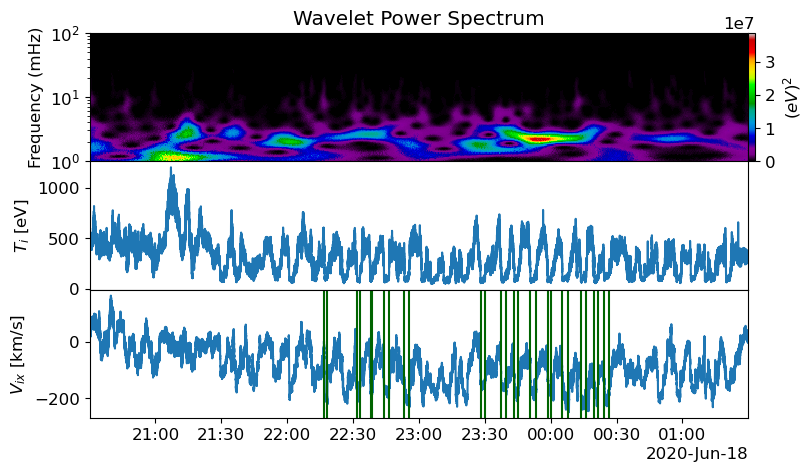

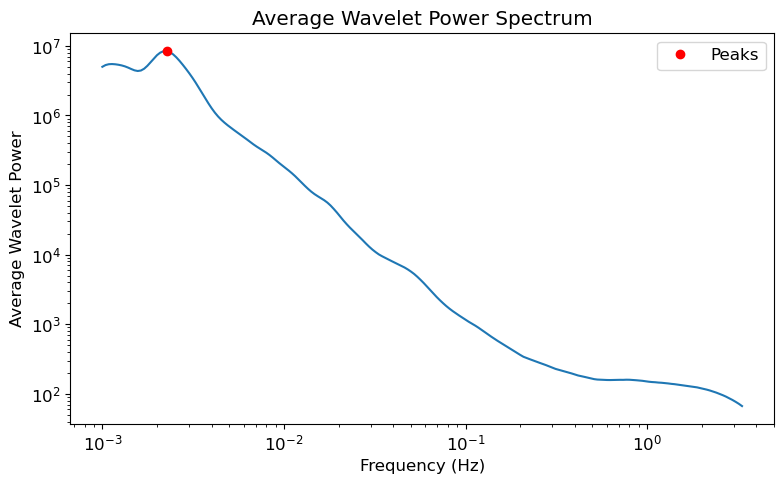

In [58]:
# Load data
df = pd.DataFrame({"times": Ti_t_para_brst, "Ti": ave_Ti_brst})



# Run analysis
results = wavelet_spectrum_analysis(
    data=df,
    time_col='times',
    value_col='Ti'
)

In [48]:
np.array(time_string(MSH_times)).astype("datetime64[ns]")

array(['2020-06-17T22:16:50.000000000', '2020-06-17T22:18:20.000000000',
       '2020-06-17T22:31:50.000000000', '2020-06-17T22:33:00.000000000',
       '2020-06-17T22:38:00.000000000', '2020-06-17T22:38:40.000000000',
       '2020-06-17T22:44:10.000000000', '2020-06-17T22:46:30.000000000',
       '2020-06-17T22:53:20.000000000', '2020-06-17T22:55:30.000000000',
       '2020-06-17T23:28:10.000000000', '2020-06-17T23:30:00.000000000',
       '2020-06-17T23:37:30.000000000', '2020-06-17T23:39:40.000000000',
       '2020-06-17T23:43:20.000000000', '2020-06-17T23:45:10.000000000',
       '2020-06-17T23:50:40.000000000', '2020-06-17T23:53:20.000000000',
       '2020-06-17T23:58:40.000000000', '2020-06-18T00:00:20.000000000',
       '2020-06-18T00:05:20.000000000', '2020-06-18T00:08:00.000000000',
       '2020-06-18T00:13:40.000000000', '2020-06-18T00:16:00.000000000',
       '2020-06-18T00:19:40.000000000', '2020-06-18T00:21:40.000000000',
       '2020-06-18T00:24:20.000000000', '2020-06-18

In [39]:

# import pandas as pd
# import numpy as np

# # Load velocity data
# df = MMS2_Vi

# # Start/stop times of MSH
# times = [
#     1592432210.0000000,1592432300.0000000,
#     1592433110.0000000,1592433180.0000000,
#     1592433480.0000000,1592433520.0000000,
#     1592433850.0000000,1592433990.0000000,
#     1592434400.0000000,1592434530.0000000,
#     1592436490.0000000,1592436600.0000000,
#     1592437050.0000000,1592437180.0000000,
#     1592437400.0000000,1592437510.0000000,
#     1592437840.0000000,1592438000.0000000,
#     1592438320.0000000,1592438420.0000000,
#     1592438720.0000000,1592438880.0000000,
#     1592439220.0000000,1592439360.0000000,
#     1592439580.0000000,1592439700.0000000,
#     1592439860.0000000,1592439990.0000000
# ]

# # Compute average Vx in each interval
# for i in range(0, len(times), 2):

#     t1 = times[i]
#     t2 = times[i+1]

#     mask = (
#         (df['times'] >= t1) &
#         (df['times'] <= t2)
#     )

#     mean_vx = df.loc[mask, 'Vix'].mean()

#     print(
#         f"{t1:.0f} - {t2:.0f} : "
#         f"Mean Vx = {mean_vx:.2f} km/s"
#     )

# vx_values = np.array([
#     -176.79,
#     -187.17,
#     -180.38,
#     -174.23,
#     -197.87,
#     -156.42,
#     -159.02,
#     -170.63,
#     -171.38,
#     -168.21,
#     -190.39,
#     -206.90,
#     -181.79,
#     -192.46
# ])

# overall_average_vx = np.mean(vx_values)

# print('overall_average_vx',overall_average_vx)


# Ave_Vx_MSH = -179.54571428571427 # average Vx over a series of time intervals in the MSH

# Ave_period = 442.529 

# lambda_KH = Ave_Vx_MSH*Ave_period

# print(lambda_KH//6378)

1592432210 - 1592432300 : Mean Vx = -176.79 km/s
1592433110 - 1592433180 : Mean Vx = -187.17 km/s
1592433480 - 1592433520 : Mean Vx = -180.38 km/s
1592433850 - 1592433990 : Mean Vx = -174.23 km/s
1592434400 - 1592434530 : Mean Vx = -197.87 km/s
1592436490 - 1592436600 : Mean Vx = -156.42 km/s
1592437050 - 1592437180 : Mean Vx = -159.02 km/s
1592437400 - 1592437510 : Mean Vx = -170.63 km/s
1592437840 - 1592438000 : Mean Vx = -171.38 km/s
1592438320 - 1592438420 : Mean Vx = -168.21 km/s
1592438720 - 1592438880 : Mean Vx = -190.39 km/s
1592439220 - 1592439360 : Mean Vx = -206.90 km/s
1592439580 - 1592439700 : Mean Vx = -181.79 km/s
1592439860 - 1592439990 : Mean Vx = -192.46 km/s
overall_average_vx -179.54571428571427
-13.0


In [40]:
(179.54571428571427*442.529)/6378

12.45753925950813

In [41]:
(180*442.529)/6378

12.489059266227658